In [1]:
import os
import glob

import torch
import torch.nn.functional as F

import numpy as np
import xarray as xr
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
from tqdm.notebook import tqdm

import rasterio as rio

import skimage as ski

from model import UNet
model_path = '/home/rpdemilt/SIG/fuels/eo-fuels-extrapolation/outputs/checkpoints/final_p26.pth'

lf_dir = '/home/rpdemilt/SIG/fuels/eo-fuels-extrapolation/data/FBFM40/LF2024_FBFM40_250_CONUS/CSV_Data/LF24_F40_250.csv'

FM40_LABELS = [
    91, 92, 93, 98, 99,
    101, 102, 103, 104, 105, 106, 107, 108, 109,
    121, 122, 123, 124,
    141, 142, 143, 144, 145, 146, 147, 148, 149,
    161, 162, 163, 164, 165,
    181, 182, 183, 184, 185, 186, 187, 188, 189,
    201, 202, 203, 204,
]

fuel_groups = {
    'NB':[91, 92, 93, 98, 99],
    'GR':[101, 102, 103, 104, 105, 106, 107, 108, 109],
    'GS':[121, 122, 123, 124],
    'SH':[141, 142, 143, 144, 145, 146, 147, 148, 149],
    'TU':[161, 162, 163, 164, 165],
    'TL':[181, 182, 183, 184, 185, 186, 187, 188, 189],
    'SB':[201, 202, 203, 204]
    }


dropped_labels = [91,92,93,98,99]

valid_labels = [label for label in FM40_LABELS if all([label != drop for drop in dropped_labels])]

def make_label_encoder(valid_labels):
    label_map = dict(zip(valid_labels,np.arange(len(valid_labels))))
    label_map[-1] = -1
    
    inv_label_map = {v:k for k,v in label_map.items()}

    def encode_fn(x):
        return label_map[x]
    
    def decode_fn(x):
        return inv_label_map[x]
    
    label_encode = np.vectorize(encode_fn)
    label_decode = np.vectorize(decode_fn)
    
    return label_encode, label_decode

label_encoder, label_decoder = make_label_encoder(valid_labels)

lfdf = pd.read_csv(lf_dir)
lf_colors = dict(zip(lfdf['VALUE'],zip(lfdf['R'],lfdf['G'],lfdf['B'])))

In [2]:
model = UNet(n_channels=64,n_classes=40)
model.load_state_dict(torch.load(model_path,weights_only=True,map_location=torch.device('cpu')))
model.eval()

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


In [3]:
pyromes = [26,4,45]

results = {}

for pyrome in pyromes:
    exp_name = f'p{pyrome}-comparisons'
    results_file = f'./results/{exp_name}/results.csv'
    results_df = pd.read_csv(results_file)
    results[pyrome] = results_df

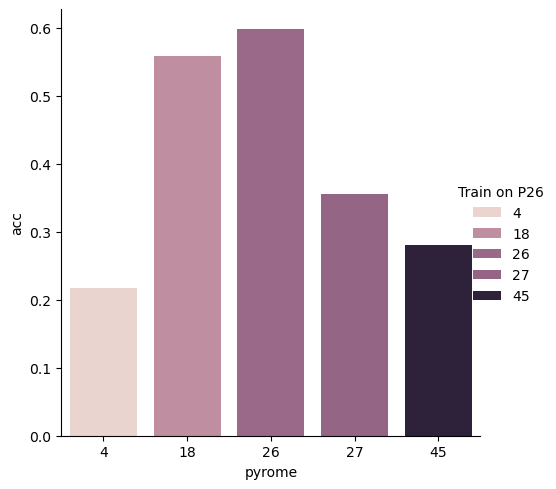

In [4]:
# PNW mesic conifer - 2,+4,32
# CA dry conifer - +26,+27,+18
# Continental Divide 8,45,12

p26_agg= results[26].groupby('pyrome').mean()

g = sns.catplot(data=p26_agg,kind='bar',x='pyrome',y='acc',hue='pyrome')
g.legend.set_title('Train on P26')

In [46]:
inference_results_dir = './results/p26-inference/'
target_pyrome = 26

tilenums = glob.glob(os.path.join(inference_results_dir,str(target_pyrome),'*'))

t_0 = tilenums[4]

pred_src = rio.open(os.path.join(t_0,'pred_tile.tif'))
label_src = rio.open(os.path.join(t_0,'label_tile.tif'))
topk_src = rio.open(os.path.join(t_0,'topk_tile.tif'))

pred_tile = label_decoder(pred_src.read())
label_tile = label_decoder(label_src.read())
topk_tile = label_decoder(topk_src.read())

n_top_k = topk_tile.shape[0]

In [47]:
matches = (label_tile == topk_tile)
#concat a column for no match
matches = np.concatenate([~np.any(matches,axis=0,keepdims=True),matches],axis=0)
kth_match = np.argmax(matches,axis=0)


#Q: For each fuel model what is the most common k at which it is predicted
k_results = []
for fuel_model in valid_labels:
    fm_kmatch = kth_match[label_tile[0] == fuel_model]
    vals , counts = np.unique(fm_kmatch,return_counts=True)
    pcts = counts / np.sum(counts)
    for val,count,pct in zip(vals,counts,pcts):
        k_results.append({'FBFM40':fuel_model,'k':int(val),'count':count,'pct':pct})

k_results = pd.DataFrame.from_records(k_results)

In [48]:
import plotly.express as px

group = 'GS'
selected_labels = fuel_groups[group]
df = k_results[k_results['FBFM40'].isin(selected_labels)]
fig = px.bar(df,x='FBFM40',y='pct',color='k',barmode='group',title='Top-k classification percentages')

fig.show()

In [49]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

app = Dash(__name__)

app.layout = html.Div([
    html.H4('Kth prediction percentage by fuel group'),
    dcc.Dropdown(
        id='dropdown',
        options=['GR','GS','SH','TU','TL','SB'],
        value ='GR',
        clearable=False
    ),
    dcc.Graph(id='graph')
])

@app.callback(
    Output('graph','figure'),
    Input('dropdown','value'))
def update_bar_chart(group):
    selected_labels = fuel_groups[group]
    df = k_results[k_results['FBFM40'].isin(selected_labels)]
    fig = px.bar(df,x='FBFM40',y='count',color='k',barmode='group')

    return fig

app.run(debug=True)

In [50]:
topk_tile.shape

(5, 1760, 1760)

In [51]:
#Q: For each fuel model what are the most common classes in its local neighborhood?

neighborhood_results = {}
for fuel_model in valid_labels:
    neighborhood_results[fuel_model] = {}

    mask = (label_tile[0] == fuel_model)
    fm_kmatch = np.transpose(topk_tile,(1,2,0))[mask].T
    for i in range(fm_kmatch.shape[0]):
        values, counts = np.unique(fm_kmatch[i],return_counts=True)
        neighborhood_results[fuel_model][i] = dict(zip(values,counts))

neighborhood_results = pd.concat({k:pd.DataFrame(v).T for k,v in neighborhood_results.items()},axis=0)
neighborhood_results = neighborhood_results.fillna(0)

In [52]:
nb_results_agg = neighborhood_results.groupby(level=0).sum()

nb_most_often_neighbors = pd.DataFrame(nb_results_agg.apply(lambda x: x.nlargest(5).index.tolist(),axis=1).tolist(),columns=['First','Second','Third','Fourth','Fifth'],index=nb_results_agg.index)

nb_most_often_neighbors.mask((nb_results_agg.sum(axis=1) == 0),level=0)

,First,Second,Third,Fourth,Fifth
101,122.0,144.0,161.0,165.0,102.0
102,122.0,102.0,101.0,121.0,144.0
103,144.0,102.0,122.0,145.0,103.0
104,NaN,NaN,NaN,NaN,NaN
105,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,NaN,NaN
107,NaN,NaN,NaN,NaN,NaN
108,NaN,NaN,NaN,NaN,NaN
109,NaN,NaN,NaN,NaN,NaN
121,122.0,165.0,144.0,102.0,142.0
